# 21 -- Sledgehamr resolution/integrator study vs CHW Fig. 8

Compares CHW Fig. 8 (published, digitized, $N_b=64$, $\gamma_*=3.94$,
$t/R_*=2$) against our own local 3+1D sledgehamr runs of the same matched
case at several different integrators/resolutions/stencils, plus our 1+1D
surrogate reconstruction -- all in the same CHW dimensionless units.

Ported from `scripts/plot_cutting_fig8_overlay.py` (`scripts/` was never
meant to hold anything semi-permanent) -- same computation, no logic
changes.

Local runs compared (`sledgehamr_runs/Cutting_lb0.84_N64_g3.94_*`):
- leapfrog, $1024^3$, stencils 7, 13, 19
- leapfrog, $2048^3$
- RKN4, $1024^3$
- RKN4, $2048^3$ (plain, stencil 19, and with AMR)

The AMR run (`..._RKN4_2048AMR`) reaches $t/R_*=2.0000$ and lies very close
to the non-AMR RKN4 $2048^3$ curve (see `AI_HANDOFF.md`'s "Sledgehamr
resolution study" section for the original notes).

In [136]:
import glob
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rc
from matplotlib import rcParams
import matplotlib.patheffects as pe
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

import ptbuilder as pt
from ptbuilder.analysis import apply_keffsq

ROOT = Path(pt.__file__).parent.parent

RUNS = [
    ("Leapfrog, $1024^3$, 7-pt stencil", "Cutting_lb0.84_N64_g3.94_leapfrog_1024_7pt", "black", "--"),
    ("Leapfrog, $1024^3$, 13-pt stencil", "Cutting_lb0.84_N64_g3.94_leapfrog_1024_13pt", "black", ":"),
    ("Leapfrog, $1024^3$, 19-pt stencil", "Cutting_lb0.84_N64_g3.94_leapfrog_1024_19pt", "black", "-"),
  #  ("Leapfrog, $2048^3$, 13-pt stencil", "Cutting_lb0.84_N64_g3.94_leapfrog_2048", "red", "--"),
  #  ("RKN4, $1024^3$, 13-pt stencil", "Cutting_lb0.84_N64_g3.94_RKN4_1024", "orange", "--"),
    #("RKN4, $2048^3$, 13-pt stencil", "Cutting_lb0.84_N64_g3.94_RKN4_2048", "#e377c2", "-"),
    ("RKN4, $2048^3$, 19-pt stencil", "Cutting_lb0.84_N64_g3.94_RKN4_2048_19pt", "blue", "-"),
    ("RKN4, $2048^3$+AMR, 13-pt stencil", "Cutting_lb0.84_N64_g3.94_RKN4_2048AMR", "orange", "--"),
]

L          = 225.28
RSTAR      = 56.32
LAMBDA_BAR = 0.84

## 1. Helpers: CHW unit conversion and loading each run's latest spectrum

In [137]:
def rho_vac_bar(lambda_bar):
    """False-minus-true vacuum energy in BM dimensionless units."""
    upsilon = 3.0 + np.sqrt(9.0 - 8.0 * lambda_bar)
    return -(0.5 - upsilon / (4.0 * lambda_bar) + upsilon**2 / (32.0 * lambda_bar))


def load_latest_spectrum(run):
    """Latest available gw_spectra/*/spectra.hdf5 snapshot for a sledgehamr run dir."""
    candidates = []
    for filename in glob.glob(str(run / "gw_spectra/*/spectra.hdf5")):
        with h5py.File(filename, "r") as handle:
            time = float(np.asarray(handle["Header"]).reshape(-1)[0])
        candidates.append((time, Path(filename)))
    time, filename = max(candidates)
    with h5py.File(filename, "r") as handle:
        k_sq = apply_keffsq(np.asarray(handle["k"][:]))
        spectrum = np.asarray(handle["Spectrum"][:])
    return time, k_sq, spectrum


def convert_local(run, box_length=L, rstar=RSTAR):
    """Load a run's latest spectrum and convert to CHW (x, y) units."""
    time, k_sq, spectrum = load_latest_spectrum(run)
    if k_sq[0] == 0:
        k_sq, spectrum = k_sq[1:], spectrum[1:]
    r = np.sqrt(k_sq)
    k = (2.0 * np.pi / box_length) * r
    dE_dlnk = spectrum * 4.0 * (2.0 * np.pi * r) * box_length**3
    x = k * rstar
    y = (3.0 / (8.0 * np.pi * rho_vac_bar(LAMBDA_BAR)**2 * rstar**2 * box_length**3)) * dE_dlnk
    return time, x, y

## 2. Load reference data, convert every local run, and plot

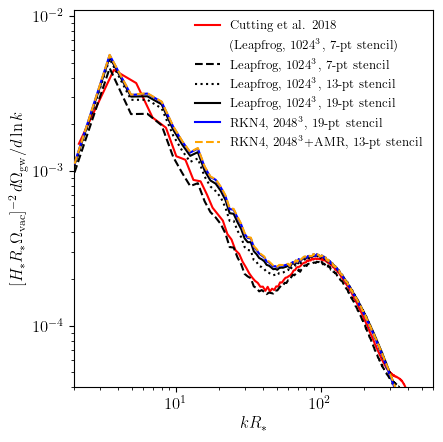

In [145]:
fig8 = np.loadtxt(
    ROOT / "reference_codes/FirstOrder_GW/collision_weights/Weir1802/fig8_lattice_tR2.txt",
    delimiter=",",
)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(fig8[:, 0], fig8[:, 1], color="red", lw=1.5,
        label="Cutting et al. 2018")
ax.plot([0],[0],label="(Leapfrog, $1024^3$, 7-pt stencil)", color='White')
visible_x = [fig8[fig8[:, 1] >= 1e-4, 0]]

for label, dirname, color, linestyle in RUNS:
    run = ROOT / "sledgehamr_runs" / dirname
    time, x_local, y_local = convert_local(run)
    ax.plot(x_local, y_local, color=color, ls=linestyle, lw=1.5,
            label=rf"{label}", zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(2, 600)
ax.set_ylim(4e-5, 1.1e-2)
ax.set_xlabel(r"$kR_*$", fontsize=12)
ax.set_ylabel(r"$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$", fontsize=12)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
ax.tick_params(axis='both', labelsize=12)
fig.savefig("plots/resolution.pdf", bbox_inches="tight")
plt.show()